# Detección de anomalías

La detección de anomalías (*anomaly detection*, AD) es una tarea de aprendizaje automático que consiste en detectar *outliers* o datos fuera de rango.

*An outlier is an observation in a data set which appears to be inconsistent with the remainder of that set of data.*
Johnson 1992

*An outlier is an observation which deviates so much from the other observations as to arouse suspicions that it was generated by a different mechanism.*
  Outlier/Anomaly
Hawkins 1980

## Tipos de entornos en los que se produce la detección de anomalías

- AD supervisada

    - Las etiquetas están disponibles, tanto para casos normales como para casos anómalos.
    - En cierto modo, similar a minería de clases poco comunes o clasificación no balanceada.
    
    
    
- AD Semi-supervisada (detección de novedades, *Novelty Detection*)

    - Durante el entrenamiento, solo tenemos datos normales.
    - El algoritmo aprende únicamente usando los datos normales.
    
    
    
- AD no supervisada (detección de outliers, *Outlier Detection*)

    - No hay etiquetas y el conjunto de entrenamiento tiene datos normales y datos anómalos.
    - Asunción: los datos anómalos son poco frecuentes.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

Vamos a familiarizarnos con la detección de anomalías no supervisada. Para visualizar la salida de los distintos algoritmos, vamos a considerar un dataset bidimensional que consiste en una mixtura de Gaussianas.

### Generando el dataset

In [36]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_features=2, centers=3, n_samples=500,
                  random_state=666)

In [37]:

print(X.shape)
print(y.shape)
print("Etiquetas:\n")
print(y)
print("Numero de valores de cada etiqueta:\n")
print(np.bincount(y))

(500, 2)
(500,)
Etiquetas:

[2 2 2 2 1 0 0 2 2 1 1 2 2 1 0 2 1 1 2 1 0 0 0 2 1 2 2 0 0 1 2 2 0 0 0 2 0
 2 1 0 0 0 2 0 2 1 0 1 1 1 2 1 2 1 2 2 0 1 2 1 0 0 2 1 0 2 1 1 1 1 2 2 2 0
 2 2 0 0 2 1 2 0 1 1 1 2 1 0 0 0 2 2 0 0 2 0 1 2 0 2 1 1 1 0 1 1 0 0 1 1 1
 1 1 0 2 0 2 0 2 1 0 0 0 0 2 2 0 2 0 2 2 0 0 0 1 0 0 0 1 1 2 2 1 0 1 1 0 1
 0 2 1 1 2 0 1 1 2 2 1 0 1 0 0 1 1 2 1 0 0 1 0 1 2 0 1 0 1 0 2 0 1 2 0 0 0
 1 2 0 2 1 0 0 1 1 1 2 0 1 0 2 0 2 1 2 2 0 0 0 1 1 1 0 1 1 1 2 2 1 2 1 1 0
 0 2 1 2 0 2 1 0 2 0 1 0 0 0 0 0 0 0 2 2 1 0 1 2 1 2 2 1 2 0 0 2 1 0 0 2 0
 0 2 1 2 1 2 2 2 2 0 2 1 1 2 0 2 1 1 2 1 1 2 0 1 1 2 2 1 2 2 1 2 0 0 0 2 2
 1 0 1 1 1 2 0 1 2 1 0 2 1 1 1 1 2 0 2 2 0 0 2 0 2 1 2 1 0 1 2 1 1 1 1 1 0
 1 0 2 1 1 1 2 2 2 2 1 1 0 1 2 0 0 0 2 0 2 2 1 2 2 1 0 0 1 2 0 0 0 1 1 2 0
 2 0 1 0 2 0 0 2 1 0 0 2 1 2 2 2 2 0 2 0 1 1 2 2 2 1 0 0 2 0 1 2 2 2 2 1 2
 1 2 0 1 1 0 0 0 2 2 0 0 1 1 1 1 2 2 0 2 1 0 1 2 1 0 2 0 1 1 0 1 0 0 2 0 2
 2 0 1 1 0 2 2 1 0 2 1 0 0 0 1 2 0 0 0 2 1 0 1 1 1 1 1 2 0 1 1 0 1 0 2 2

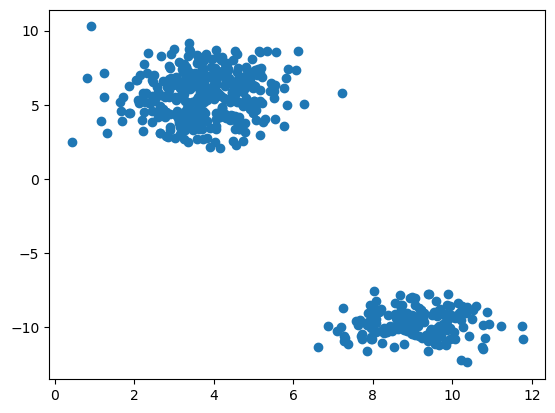

In [38]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.show()

## Detección de anomalías con estimación de densidad

In [39]:
from sklearn.neighbors import KernelDensity

# Estimador de densidad Gaussiano
kde = KernelDensity(kernel='gaussian')
kde = kde.fit(X)
kde

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",1.0
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


In [40]:
kde_X = kde.score_samples(X)
print(kde_X.shape)  # nos proporciona la verosimilitud de los datos. Cuanto más baja, más anómalo

(500,)


In [41]:
# Importar función para calcular cuantiles
from scipy.stats.mstats import mquantiles

# Establecer el nivel de confianza al 95% (solo el 5% de los datos se considerarán anómalos)
alpha_set = 0.95

# Calcular el cuantil de densidad correspondiente al nivel de significancia (5%)
# 1 - alpha_set = 0.05, por lo que tau_kde es el valor por debajo del cual está el 5% de los datos
# Este umbral se usará para identificar anomalías: puntos con densidad por debajo de tau_kde ser anómalos
tau_kde = mquantiles(kde_X, 1. - alpha_set)

In [42]:
# Obtener el número de muestras y características del dataset
n_samples, n_features = X.shape

# Crear una matriz para almacenar el rango de valores de cada característica
X_range = np.zeros((n_features, 2))

# Encontrar el valor mínimo de cada característica y restar 1 para el margen visual
X_range[:, 0] = np.min(X, axis=0) - 1.

# Encontrar el valor máximo de cada característica y sumar 1 para el margen visual
X_range[:, 1] = np.max(X, axis=0) + 1.

# Tamaño de paso de la rejilla para la malla de visualización
h = 0.1

# Extraer los rangos mínimos y máximos para cada eje
x_min, x_max = X_range[0]
y_min, y_max = X_range[1]

# Crear una malla rectangular de puntos (xx, yy) cubriendo el espacio 2D
# np.arange genera arrays con paso h, np.meshgrid crea la malla de coordenadas
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Convertir la malla 2D a una matriz 2D de coordenadas (N, 2) para hacer predicciones
# ravel() aplana los arrays, np.c_ concatena columnas
grid = np.c_[xx.ravel(), yy.ravel()]

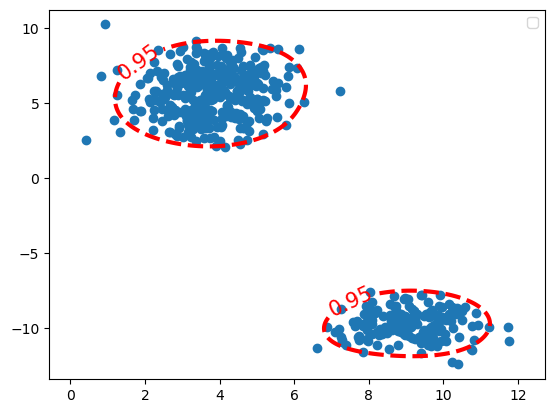

In [43]:
# Calcular la puntuación de densidad (log-verosimilitud) para cada punto de la malla
# Cuanto más bajo el valor, más anómalo es el punto
Z_kde = kde.score_samples(grid)

# Remodelar el array Z_kde para que tenga la misma forma que la malla (xx, yy)
# Esto es necesario para poder representarlo como una superficie 2D
Z_kde = Z_kde.reshape(xx.shape)

# Crear una nueva figura para el gráfico
plt.figure()

# Dibujar contornos (isolíneas) donde la densidad es igual a tau_kde (el umbral del 5%)
# Esto marca el límite de la región donde están los datos normales
# levels=tau_kde especifica el valor del umbral de densidad
# colors='red' hace que las líneas sean rojas
# linewidths=3 establece el ancho de las líneas en 3 puntos
c_0 = plt.contour(xx, yy, Z_kde, levels=tau_kde, colors='red', linewidths=3)

# Añadir etiquetas a las líneas de contorno mostrando el valor de alpha_set (0.95)
# inline=1 coloca las etiquetas dentro de las líneas
# fontsize=15 establece el tamaño de fuente
plt.clabel(c_0, inline=1, fontsize=15, fmt={tau_kde[0]: str(alpha_set)})

# Representar los datos originales como puntos de dispersión
# X[:, 0] son las coordenadas X, X[:, 1] son las coordenadas Y
plt.scatter(X[:, 0], X[:, 1])

# Mostrar la leyenda con los elementos del gráfico
plt.legend()

# Mostrar el gráfico en pantalla
plt.show()

## One-Class SVM

El problema de usar la estimación de densidad es que es ineficiente cuando la dimensionalidad de los datos es demasiado alta. El algoritmo *one-class SVM* si que puede utilizarse en estos casos.

In [44]:
from sklearn.svm import OneClassSVM

In [45]:
nu = 0.05  # Resultados teóricos dicen que hay un 5% de datos anómalos
ocsvm = OneClassSVM(kernel='rbf', gamma=0.05, nu=nu)
ocsvm.fit(X)
filas, columnas = X.shape
print(f'filas de X:', filas, 'columnas de X:', columnas)
print(f'Numero de etiquetas:', y.shape)
print("Recordamos las etiquetas y (3 clases):\n")
print(y)
print("Numero de valores de cada etiqueta:\n")
print(np.bincount(y))

filas de X: 500 columnas de X: 2
Numero de etiquetas: (500,)
Recordamos las etiquetas y (3 clases):

[2 2 2 2 1 0 0 2 2 1 1 2 2 1 0 2 1 1 2 1 0 0 0 2 1 2 2 0 0 1 2 2 0 0 0 2 0
 2 1 0 0 0 2 0 2 1 0 1 1 1 2 1 2 1 2 2 0 1 2 1 0 0 2 1 0 2 1 1 1 1 2 2 2 0
 2 2 0 0 2 1 2 0 1 1 1 2 1 0 0 0 2 2 0 0 2 0 1 2 0 2 1 1 1 0 1 1 0 0 1 1 1
 1 1 0 2 0 2 0 2 1 0 0 0 0 2 2 0 2 0 2 2 0 0 0 1 0 0 0 1 1 2 2 1 0 1 1 0 1
 0 2 1 1 2 0 1 1 2 2 1 0 1 0 0 1 1 2 1 0 0 1 0 1 2 0 1 0 1 0 2 0 1 2 0 0 0
 1 2 0 2 1 0 0 1 1 1 2 0 1 0 2 0 2 1 2 2 0 0 0 1 1 1 0 1 1 1 2 2 1 2 1 1 0
 0 2 1 2 0 2 1 0 2 0 1 0 0 0 0 0 0 0 2 2 1 0 1 2 1 2 2 1 2 0 0 2 1 0 0 2 0
 0 2 1 2 1 2 2 2 2 0 2 1 1 2 0 2 1 1 2 1 1 2 0 1 1 2 2 1 2 2 1 2 0 0 0 2 2
 1 0 1 1 1 2 0 1 2 1 0 2 1 1 1 1 2 0 2 2 0 0 2 0 2 1 2 1 0 1 2 1 1 1 1 1 0
 1 0 2 1 1 1 2 2 2 2 1 1 0 1 2 0 0 0 2 0 2 2 1 2 2 1 0 0 1 2 0 0 0 1 1 2 0
 2 0 1 0 2 0 0 2 1 0 0 2 1 2 2 2 2 0 2 0 1 1 2 2 2 1 0 0 2 0 1 2 2 2 2 1 2
 1 2 0 1 1 0 0 0 2 2 0 0 1 1 1 1 2 2 0 2 1 0 1 2 1 0 2 0 1 1 0 1 0 0 2 0 2

In [46]:
# En un One‑Class SVM, los valores 1 y −1 indican normalidad vs anomalía:
#  1: muestra considerada “normal” (inlier) según el modelo.
# -1: muestra considerada “anómala” (outlier).

predictions_vector = ocsvm.predict(X)
print("Shape de predictions_vector:", predictions_vector.shape)
print("predictions_vector:\n", predictions_vector)

# Extraer las muestras que el modelo considera anómalas (outliers), es decir, solo las que valen -1 en predictions_vector
X_outliers = X[predictions_vector == -1]
number_outliers = X_outliers.shape[0]
print(f'Número de muestras consideradas anómalas por el modelo: {number_outliers}')
print(f'Muestras anómalas:\n{X_outliers}')

Shape de predictions_vector: (500,)
predictions_vector:
 [ 1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1 -1  1 

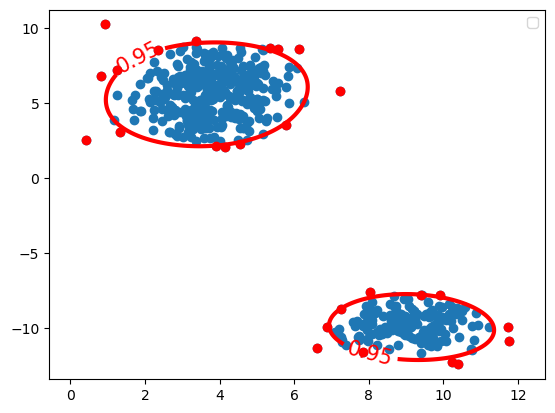

In [47]:
# Calcular la función de decisión del One-Class SVM para cada punto de la malla
# La función de decisión mide la distancia con signo al hiperplano de separación
# Valores positivos = región normal, valores negativos = región anómala
Z_ocsvm = ocsvm.decision_function(grid)

# Remodelar el array para que tenga la misma forma que la malla (xx, yy)
# Esto permite visualizar la función de decisión como una superficie 2D
Z_ocsvm = Z_ocsvm.reshape(xx.shape)

# Crear una nueva figura para el gráfico
plt.figure()

# Dibujar el contorno donde la función de decisión es 0 (frontera de decisión)
# levels=[0] indica que solo dibujamos la línea donde Z_ocsvm = 0
# Esta línea roja separa la región normal (interior) de la anómala (exterior)
c_0 = plt.contour(xx, yy, Z_ocsvm, levels=[0], colors='red', linewidths=3)

# Añadir etiqueta al contorno mostrando el valor de alpha_set (0.95)
# inline=1 coloca la etiqueta sobre la línea de contorno
plt.clabel(c_0, inline=1, fontsize=15, fmt={0: str(alpha_set)})

# Representar todos los datos originales como puntos azules
plt.scatter(X[:, 0], X[:, 1])

# Resaltar las anomalías detectadas (predictions_vector == -1) en rojo
# Estos puntos están fuera de la frontera de decisión
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], color='red')

# Mostrar la leyenda del gráfico
plt.legend()

# Mostrar el gráfico en pantalla
plt.show()

### Vectores soporte o outliers

En el one-class SVM, no todos los vectores soporte son outliers:

In [48]:
X_SV = X[ocsvm.support_]
n_SV = len(X_SV)
n_outliers = len(X_outliers)

print('{0:.2f} <= {1:.2f} <= {2:.2f}?'.format(1./n_samples*n_outliers, nu, 1./n_samples*n_SV))

0.05 <= 0.05 <= 0.06?


Solo los vectores soporte sirven a la hora de calcular la función de decisión del One-Class SVM.

Ahora vamos a representar la función de decisión del One-Class SVM como hicimos con la densidad y vamos a marcar los vectores soporte.

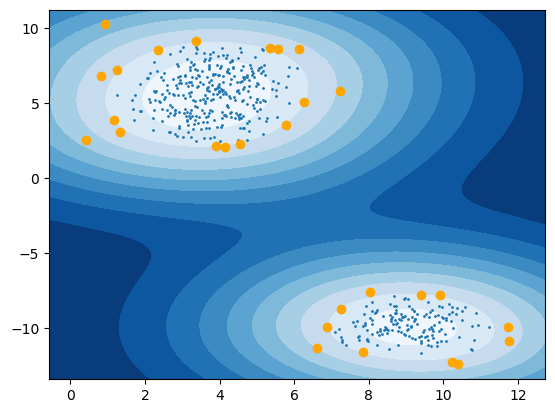

In [49]:
plt.figure()
plt.contourf(xx, yy, Z_ocsvm, 10, cmap=plt.cm.Blues_r)
plt.scatter(X[:, 0], X[:, 1], s=1.)
plt.scatter(X_SV[:, 0], X_SV[:, 1], color='orange')
plt.show()

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      **Cambia** el parámetro `gamma` y comprueba como afecta la función de decisión.
      </li>
    </ul>
</div>

## *Isolation Forest*

El algoritmo *Isolation Forest* es un algoritmo de AD basado en árboles. Construye un determinado número de árboles aleatorios y su idea principal es que si un ejemplo es una anomalía, entonces debería aparecer aislado en la hoja de un árbol tras algunas particiones. El *Isolation Forest* deriva una puntuación de anormalidad basada en la profundidad del árbol en la cuál términos los ejemplos anómalos.

In [50]:
from sklearn.ensemble import IsolationForest

In [ ]:
# contamination=0.10 indica que vamos a buscar el 10% de los datos más anómalos
iforest = IsolationForest(n_estimators=300, contamination=0.10)
print(f'Recordamos el shape de X: {X.shape} y las etiquetas y:\n {y}')
iforest = iforest.fit(X)

Recordamos el shape de X: (500, 2) y las etiquetas y:
 [2 2 2 2 1 0 0 2 2 1 1 2 2 1 0 2 1 1 2 1 0 0 0 2 1 2 2 0 0 1 2 2 0 0 0 2 0
 2 1 0 0 0 2 0 2 1 0 1 1 1 2 1 2 1 2 2 0 1 2 1 0 0 2 1 0 2 1 1 1 1 2 2 2 0
 2 2 0 0 2 1 2 0 1 1 1 2 1 0 0 0 2 2 0 0 2 0 1 2 0 2 1 1 1 0 1 1 0 0 1 1 1
 1 1 0 2 0 2 0 2 1 0 0 0 0 2 2 0 2 0 2 2 0 0 0 1 0 0 0 1 1 2 2 1 0 1 1 0 1
 0 2 1 1 2 0 1 1 2 2 1 0 1 0 0 1 1 2 1 0 0 1 0 1 2 0 1 0 1 0 2 0 1 2 0 0 0
 1 2 0 2 1 0 0 1 1 1 2 0 1 0 2 0 2 1 2 2 0 0 0 1 1 1 0 1 1 1 2 2 1 2 1 1 0
 0 2 1 2 0 2 1 0 2 0 1 0 0 0 0 0 0 0 2 2 1 0 1 2 1 2 2 1 2 0 0 2 1 0 0 2 0
 0 2 1 2 1 2 2 2 2 0 2 1 1 2 0 2 1 1 2 1 1 2 0 1 1 2 2 1 2 2 1 2 0 0 0 2 2
 1 0 1 1 1 2 0 1 2 1 0 2 1 1 1 1 2 0 2 2 0 0 2 0 2 1 2 1 0 1 2 1 1 1 1 1 0
 1 0 2 1 1 1 2 2 2 2 1 1 0 1 2 0 0 0 2 0 2 2 1 2 2 1 0 0 1 2 0 0 0 1 1 2 0
 2 0 1 0 2 0 0 2 1 0 0 2 1 2 2 2 2 0 2 0 1 1 2 2 2 1 0 0 2 0 1 2 2 2 2 1 2
 1 2 0 1 1 0 0 0 2 2 0 0 1 1 1 1 2 2 0 2 1 0 1 2 1 0 2 0 1 1 0 1 0 0 2 0 2
 2 0 1 1 0 2 2 1 0 2 1 0 0 0 1 2 0 0 0 2 1 0 

Tipo de Z_iforest: <class 'numpy.ndarray'>, shape de Z_iforest: (33098,)
Tipo de threshold: <class 'numpy.float64'>, valor de threshold: -1.194528213865377e-17


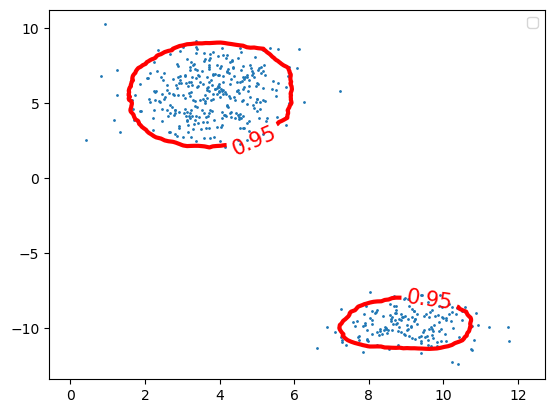

In [56]:
from scipy.stats import scoreatpercentile

# Calcular la puntuación de anomalía del Isolation Forest para cada punto de la malla
# Valores más bajos indican mayor probabilidad de ser una anomalía
Z_iforest = iforest.decision_function(grid)

print(f'Tipo de Z_iforest: {type(Z_iforest)}, shape de Z_iforest: {Z_iforest.shape}')

# Remodelar el array para que tenga la misma forma que la malla (xx, yy)
# Esto permite visualizar la función de decisión como una superficie 2D
Z_iforest = Z_iforest.reshape(xx.shape)

"""
This function will become obsolete in the future. For NumPy 1.9 and higher, numpy.percentile provides all the functionality that scoreatpercentile provides. And it’s significantly faster. Therefore it’s recommended to use numpy.percentile for users that have numpy >= 1.9.
"""
# Calcular el umbral que separa datos normales de anomalías
# Se usa scoreatpercentile para encontrar el percentil que corresponde al nivel de contaminación (10%)
# El doble negativo (-scoreatpercentile(-iforest.decision_function(X), ...)) invierte la escala
# porque valores más bajos de decision_function indican mayor anomalía
threshold = -scoreatpercentile(-iforest.decision_function(X), 100. * (1. - iforest.contamination))
print(f'Tipo de threshold: {type(threshold)}, valor de threshold: {threshold}')

plt.figure()
c_0 = plt.contour(xx, yy, Z_iforest,
                  levels=[threshold],
                  colors='red', linewidths=3)
plt.clabel(c_0, inline=1, fontsize=15,
           fmt={threshold: str(alpha_set)})
plt.scatter(X[:, 0], X[:, 1], s=1.)
plt.legend()
plt.show()

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      Ilustra gráficamente la influencia del número de árboles en la suavidad de la función de decisión
      </li>
    </ul>
</div>

# Aplicación al dataset de dígitos

Ahora vamos a aplicar el ``IsolationForest`` para intentar localizar dígitos que han sido escritos de modo poco convencional.

In [60]:
from sklearn import datasets
digits = datasets.load_digits()

print(f'Caracteristicas: {digits.feature_names}')
print(f'Etiquetas: {digits.target_names}')

Caracteristicas: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
Etiquetas: [0 1 2 3 4 5 6 7 8 9]


La base de datos de dígitos consiste en imágenes de 8x8 valores de gris.

In [71]:
# Las dimensiones representan:

# Primera dimensión (número de muestras): Cantidad total de imágenes de dígitos en el dataset (1.797 imágenes)
# Segunda dimensión (8): Alto de la imagen en píxeles
# Tercera dimensión (8): Ancho de la imagen en píxeles

# Por ejemplo:

# images[0] = primera imagen (matriz 8×8)
# images[0, 3, 5] = valor del píxel en fila 3, columna 5 de la primera imagen
# images.shape[0] = número total de imágenes

images = digits.images
print(f'Tipo de images: {type(images)}, shape de images: {images.shape}, numero de imagenes: {images.shape[0]}')

labels = digits.target
print(f'Etiquetas: {digits.target_names}')
print(f'Etiquetas de todo el dataset: {labels} y shape de etiquetas: {labels.shape}')
print(f'Numero de patrones por etiqueta: {np.bincount(labels)}')

Tipo de images: <class 'numpy.ndarray'>, shape de images: (1797, 8, 8), numero de imagenes: 1797
Etiquetas: [0 1 2 3 4 5 6 7 8 9]
Etiquetas de todo el dataset: [0 1 2 ... 8 9 8] y shape de etiquetas: (1797,)
Numero de patrones por etiqueta: [178 182 177 183 181 182 181 179 174 180]


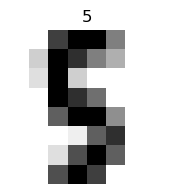

In [72]:
i = 102

plt.figure(figsize=(2, 2))
plt.title('{0}'.format(labels[i]))
plt.axis('off')
plt.imshow(images[i], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

Para usar las imágenes como patrones de entrenamiento, tenemos que pasarlas a vector:

In [73]:
# Obtener el número total de imágenes en el dataset
n_samples = len(digits.images)

# Convertir las imágenes de forma (n_samples, 8, 8) a forma (n_samples, 64)
# Cada imagen (matriz 8×8) se convierte en un vector de 64 elementos (8*8=64)
# -1 en reshape significa que NumPy calcula automáticamente esa dimensión
data = digits.images.reshape((n_samples, -1))

In [74]:
print(f'Tipo de data: {type(data)}, shape de data: {data.shape}')

Tipo de data: <class 'numpy.ndarray'>, shape de data: (1797, 64)


In [77]:
# Asignar los datos aplanados (1797 × 64) a la variable X
# Esta será la matriz de características para el modelo de aprendizaje automático
X_ = data

# Asignar las etiquetas (números del 0 al 9) a la variable y
# Cada etiqueta corresponde al dígito que representa cada imagen
y = digits.target

In [78]:
X_.shape

(1797, 64)

Vamos a centrarnos en el dígito 5.

In [ ]:
# Filtra los patrones que son de la clase 5
X_5 = X_[y == 5]

In [80]:
print(f'Total de patrones de la clase 5: {X_5.shape[0]} y shape de X_5: {X_5.shape}')

Total de patrones de la clase 5: 182 y shape de X_5: (182, 64)


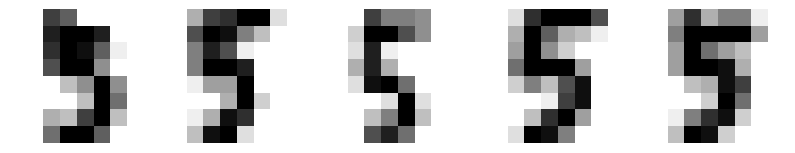

In [81]:
fig, axes = plt.subplots(1, 5, figsize=(10, 4))
for ax, x in zip(axes, X_5[:5]):
    img = x.reshape(8, 8)
    ax.imshow(img, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

Vamos a usar ``IsolationForest`` para encontrar el 5% de imágenes más anómalas y representarlas:

In [82]:
from sklearn.ensemble import IsolationForest
iforest = IsolationForest(contamination=0.05)
iforest = iforest.fit(X_5)

Sacamos el grado de anormalidad utilizando `iforest.decision_function`. Cuanto más bajo, más anómalo.

Tipo de iforest_X: <class 'numpy.ndarray'>, shape de iforest_X: (182,)


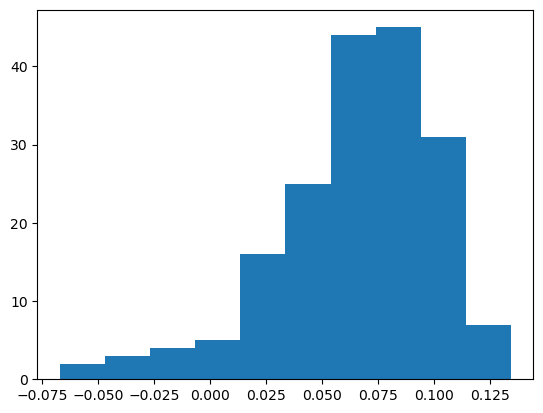

In [ ]:
# Calcular la puntuacion de anomalia para cada una de las imagenes que son de la clase 5
iforest_X = iforest.decision_function(X_5)
print(f'Tipo de iforest_X: {type(iforest_X)}, shape de iforest_X: {iforest_X.shape}')
plt.hist(iforest_X);

Dibujemos los 10 ejemplos más "normales" (*inliers*):

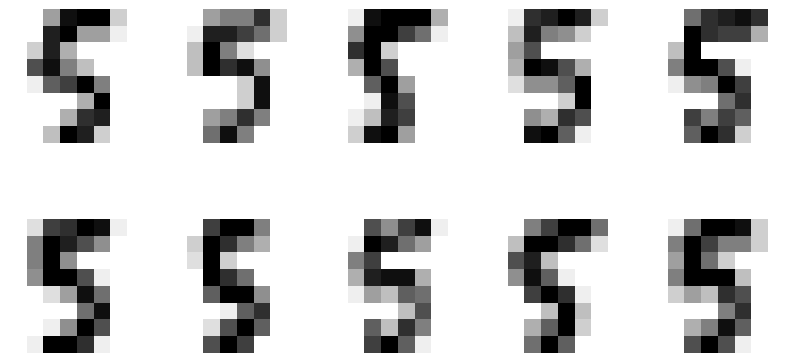

In [85]:
# Seleccionar las 10 muestras con mayor puntuacion (mas normales)
# -10 selecciona las 10 muestras con mayor puntuación (mas normales - menos anómalas) de iforest_X
# np.argsort ordena los indices de menor a mayor; el slicing [-10:] toma los ultimos 10 indices
X_strong_inliers = X_5[np.argsort(iforest_X)[-10:]]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in zip(range(len(X_strong_inliers)), axes.ravel()):
    ax.imshow(X_strong_inliers[i].reshape((8, 8)),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

Ahora vamos a dibujar los *outliers*:

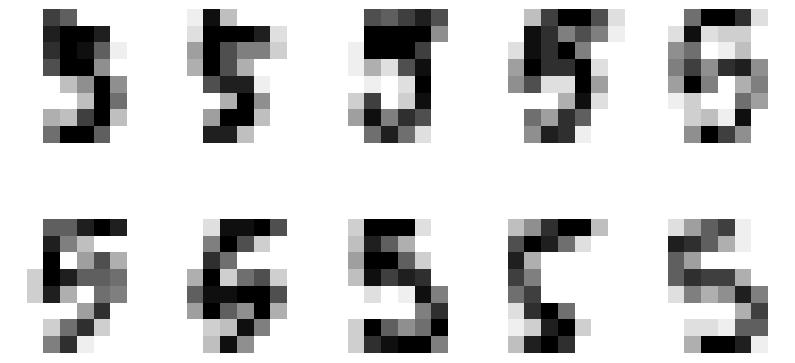

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Seleccionar las muestras que el modelo considera anomalas (-1)
X_outliers = X_5[iforest.predict(X_5) == -1]

for i, ax in zip(range(len(X_outliers)), axes.ravel()):
    ax.imshow(X_outliers[i].reshape((8, 8)),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax.axis('off')

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      Haz lo mismo pero para los dígitos 9 y 7.
      </li>
    </ul>
</div>